In [24]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import seaborn as sns

In [31]:
IMG_HEIGHT = 128
IMG_WIDTH = 128

BATCH_SIZE = 32
SEED = 42

In [32]:
dataset_path = "/workspaces/plant_disease_detection/data/raw"

In [33]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(

    dataset_path,

    validation_split=0.2,

    subset="validation",

    seed=SEED,

    image_size=(IMG_HEIGHT, IMG_WIDTH),

    batch_size=BATCH_SIZE

)

Found 20638 files belonging to 15 classes.
Using 4127 files for validation.


In [34]:
class_names = validation_dataset.class_names

print("Number of Classes:", len(class_names))

Number of Classes: 15


In [35]:
model = tf.keras.models.load_model(
    "/workspaces/plant_disease_detection/artifacts/best_model.keras"
)

In [36]:
loss, accuracy = model.evaluate(
    validation_dataset
)

129/129 ━━━━━━━━━━━━━━━━━━━━ 28s 213ms/step - accuracy: 0.6835 - loss: 0.9855


In [37]:
print(f"Validation Loss: {loss:.4f}")

print(f"Validation Accuracy: {accuracy*100:.2f}%")

Validation Loss: 0.9855
Validation Accuracy: 68.35%


In [40]:
import pickle

with open('../artifacts/history.pkl', 'rb') as file:
    history = pickle.load(file)

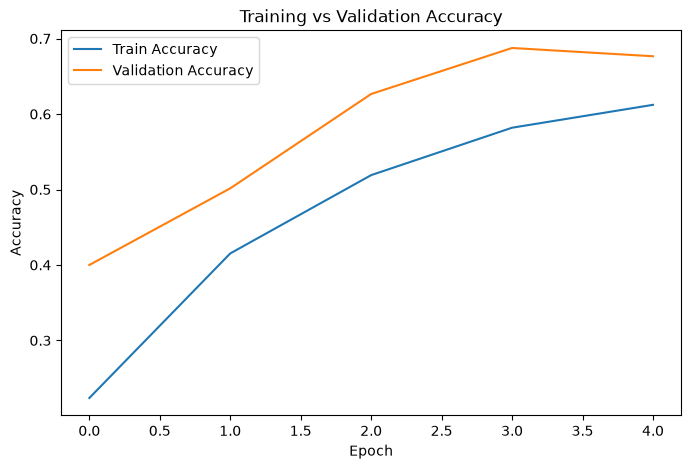

In [41]:
plt.figure(figsize=(8,5))

plt.plot(history['accuracy'],
         label='Train Accuracy')

plt.plot(history['val_accuracy'],
         label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

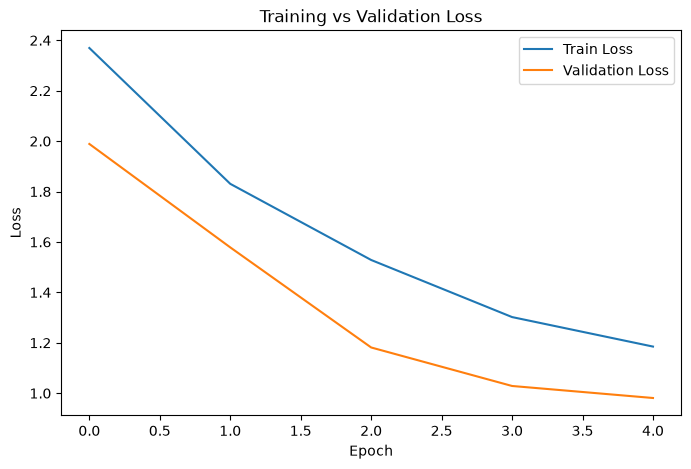

In [42]:
plt.figure(figsize=(8,5))

plt.plot(history['loss'],
         label='Train Loss')

plt.plot(history['val_loss'],
         label='Validation Loss')

plt.title('Training vs Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

In [43]:
y_true = []
y_pred = []

In [44]:
for images, labels in validation_dataset:

    predictions = model.predict(images)

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [46]:
import matplotlib as plt

In [47]:
plt.figure(figsize=(15,12))

sns.heatmap(cm,
            cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

TypeError: 'module' object is not callable